In [1]:
from contextlib import redirect_stdout
from io import StringIO
from pathlib import Path

import scarf
from scarf.agent import (
    AgentOrchestrator,
    AgentRunConfig,
    AutomatedWorkflowConfig,
    AutomatedWorkflowRequest,
    AutomatedWorkflowResumeRequest,
    generate_agent_report,
    load_agent_report,
)
from scarf.agent.orchestrator import artifact_model_to_ref

scarf.configure_output(level="WARNING", progress=False)

source_path = scarf.cytebase.connect("scarf_docs").download(
    "tenx_5K_pbmc_rnaseq/data.h5",
    destination="scarf_datasets",
)[0]
zarr_path = source_path.with_name("agent_workflow.zarr")

study_context = (
    "This is a human 10x Genomics 5K PBMC 3-prime gene-expression dataset "
    "from peripheral blood collected from one healthy donor. The goal is "
    "unsupervised identification and characterization of the major immune-cell "
    "populations. No treatment comparison, technical batch covariate, paired "
    "modality, or independent replication metadata is available. Do not invent "
    "absent design variables or report treatment effects."
)

{"source": source_path.name, "destination": zarr_path.name}

Downloading bucket files: 18098007 / 18098007 complete

Downloading bytes: 18098007 / 18098007 complete

{'source': 'data.h5', 'destination': 'agent_workflow.zarr'}

In [2]:
import re
from typing import Any

from pydantic_ai.messages import (
    ModelMessage,
    ModelResponse,
    ToolCallPart,
    ToolReturnPart,
)
from pydantic_ai.models.function import AgentInfo, FunctionModel

from scarf.agent.biological_interpretation import (
    BiologicalInterpretationReport,
    ClusterCompositionEvidence,
    ClusterInterpretation,
    ClusterMarkerBatchEvidence,
)
from scarf.agent.data_enrichment import (
    AssayFeatureInspectionBatch,
    DataEnrichmentReport,
    FeatureSelectionPolicy,
    StudyContextSummary,
)
from scarf.agent.experimental_context import (
    BatchCorrectionPlan,
    CellQcPlan,
    CovariateEvidence,
    ExperimentalContextDecision,
)
from scarf.agent.parameter_tuning import (
    FinalGraphSelection,
    ParameterTuningReport,
)


def _prompt_text(messages: list[ModelMessage]) -> str:
    return "\n".join(
        part.content
        for message in messages
        for part in message.parts
        if isinstance(getattr(part, "content", None), str)
    )


def _tool_result(
    messages: list[ModelMessage],
    tool_name: str,
    model_type: Any,
) -> Any:
    for message in reversed(messages):
        for part in reversed(message.parts):
            if isinstance(part, ToolReturnPart) and part.tool_name == tool_name:
                if isinstance(part.content, model_type):
                    return part.content
                if isinstance(part.content, str):
                    return model_type.model_validate_json(part.content)
                return model_type.model_validate(part.content)
    raise AssertionError(f"Missing tool return {tool_name!r}")


def _tool_call(name: str, args: dict[str, Any] | None = None) -> ModelResponse:
    return ModelResponse(parts=[ToolCallPart(tool_name=name, args=args or {})])


def _structured_output(info: AgentInfo, value: Any) -> ModelResponse:
    payload = value.model_dump() if hasattr(value, "model_dump") else value
    return _tool_call(info.output_tools[0].name, payload)


def _scripted_workflow_model() -> tuple[FunctionModel, dict[str, int]]:
    state = {
        "enrichment": 0,
        "context": 0,
        "parameter": 0,
        "biology": 0,
        "requests": 0,
    }

    async def reply(
        messages: list[ModelMessage],
        info: AgentInfo,
    ) -> ModelResponse:
        state["requests"] += 1
        tools = {tool.name for tool in info.function_tools}

        if "inspect_assay_features_batch" in tools or state["enrichment"] == 1:
            if state["enrichment"] == 0:
                state["enrichment"] = 1
                return _tool_call("inspect_assay_features_batch")

            batch = _tool_result(
                messages,
                "inspect_assay_features_batch",
                AssayFeatureInspectionBatch,
            )
            policies = []
            for inspection in batch.inspections:
                species_observed = inspection.species != "unknown"
                policy_evidence = list(inspection.evidenceIds)
                if not species_observed:
                    policy_evidence.append("context:study")
                policies.append(
                    FeatureSelectionPolicy(
                        assay=inspection.assay,
                        species=(
                            inspection.species
                            if species_observed
                            else "homo_sapiens"
                        ),
                        speciesConfidence="high" if species_observed else "medium",
                        speciesRationale=(
                            inspection.speciesReason
                            or "The exact study paragraph identifies a human sample."
                        ),
                        excludeFamilies=[
                            family.family
                            for family in inspection.families
                            if family.count > 0 and family.defaultExclude is True
                        ],
                        protectFamilies=[
                            family.family
                            for family in inspection.families
                            if family.count > 0 and family.defaultExclude is False
                        ],
                        rationale=(
                            "Exclude observed technical families and preserve "
                            "observed protected families."
                        ),
                        evidenceIds=list(dict.fromkeys(policy_evidence)),
                    )
                )
            state["enrichment"] = 2
            return _structured_output(
                info,
                DataEnrichmentReport(
                    status="done",
                    studyContextSummary=StudyContextSummary(
                        organismReferences=["human"],
                        tissueReferences=["peripheral blood"],
                        experimentalReferences=[
                            "10x Genomics 5K PBMC 3-prime gene-expression dataset"
                        ],
                        analysisIntentReferences=[
                            "unsupervised identification and characterization of "
                            "the major immune-cell populations"
                        ],
                    ),
                    policies=policies,
                ),
            )

        if tools.intersection(
            {
                "inspect_cell_covariates",
                "analyze_experimental_design",
                "score_current_representation",
            }
        ) or state["context"] in {1, 2}:
            if state["context"] == 0:
                state["context"] = 1
                return _tool_call("inspect_cell_covariates")
            if state["context"] == 1:
                state["context"] = 2
                return _tool_call(
                    "analyze_experimental_design",
                    {
                        "column_domains": {},
                        "coefficients_of_interest": [],
                        "units_of_inference": {},
                        "batch_columns": [],
                    },
                )

            design = _tool_result(
                messages,
                "analyze_experimental_design",
                CovariateEvidence,
            )
            profile = next(
                value
                for value in design.qcProfiles
                if value.action == "globalGaussian"
            )
            evidence_id = profile.evidenceId
            state["context"] = 3
            return _structured_output(
                info,
                ExperimentalContextDecision(
                    batchCorrection=BatchCorrectionPlan(
                        action="skip",
                        rationale="No trusted technical batch column was supplied.",
                        evidenceIds=[evidence_id],
                    ),
                    cellQc=CellQcPlan(
                        action=profile.action,
                        profileId=profile.profileId,
                        driverAssay=profile.driverAssay,
                        driverAssayType=profile.driverAssayType,
                        attributes=profile.attributes,
                        artifactMetrics=profile.artifactMetrics,
                        rationale="Apply the bounded global RNA QC profile.",
                        evidenceIds=[evidence_id],
                    ),
                    rationale="No experimental covariates were supplied.",
                    evidenceIds=[evidence_id],
                ),
            )

        if tools.intersection(
            {"inspect_cluster_composition", "inspect_cluster_markers_batch"}
        ) or state["biology"]:
            if state["biology"] == 0:
                state["biology"] = 1
                return _tool_call("inspect_cluster_composition")
            if state["biology"] == 1:
                composition = _tool_result(
                    messages,
                    "inspect_cluster_composition",
                    ClusterCompositionEvidence,
                )
                state["biology"] = 2
                return _tool_call(
                    "inspect_cluster_markers_batch",
                    {"cluster_ids": list(composition.clusterCounts)},
                )

            marker_batch = _tool_result(
                messages,
                "inspect_cluster_markers_batch",
                ClusterMarkerBatchEvidence,
            )
            interpretations = []
            for cluster in marker_batch.clusters:
                if cluster.evidenceId and cluster.markers:
                    marker = cluster.markers[0]
                    marker_name = marker.featureName or marker.featureId
                    interpretations.append(
                        ClusterInterpretation(
                            clusterId=cluster.clusterId,
                            proposedIdentity=f"{marker_name}-high RNA state",
                            identityIsHypothesis=True,
                            confidence="low",
                            rationale=(
                                "The returned marker panel is led by "
                                f"{marker_name}."
                            ),
                            evidenceIds=[cluster.evidenceId],
                        )
                    )
            state["biology"] = 3
            return _structured_output(
                info,
                BiologicalInterpretationReport(
                    status="done",
                    clusterInterpretations=interpretations,
                    evidenceIds=[item.evidenceIds[0] for item in interpretations],
                    limitations=[
                        "The scripted documentation model returns marker-linked "
                        "hypotheses, not validated cell identities."
                    ],
                    stopReason=(
                        "Every cluster with returned marker evidence was reviewed."
                    ),
                ),
            )

        prompt = _prompt_text(messages)
        if state["parameter"] == 0:
            match = re.search(
                r'"candidateId"\s*:\s*"([A-Za-z0-9_]+)"',
                prompt,
            )
            if match is None:
                raise AssertionError("The parameter prompt lacks a candidate ID")
            candidate_id = match.group(1)
            evidence_id = f"candidate:{candidate_id}:clusters"
            assay_report = ParameterTuningReport(
                status="done",
                recommendedCandidateId=candidate_id,
                confidence="high",
                rationale="The only authorized native branch is eligible.",
                evidenceIds=[evidence_id],
                stopReason="The bounded one-candidate screen completed.",
            )
            state["parameter"] = 1
            return _structured_output(
                info,
                ParameterTuningReport(
                    status="done",
                    assayReports={"RNA": assay_report},
                    rationale="The RNA native screen completed.",
                    evidenceIds=[evidence_id],
                    stopReason="Native selection completed.",
                ),
            )

        match = re.search(
            r'"optionId"\s*:\s*"(native:RNA:([A-Za-z0-9_]+))"',
            prompt,
        )
        if match is None:
            raise AssertionError("The final-selection prompt lacks a native option")
        option_id, candidate_id = match.groups()
        evidence_id = f"native:RNA:candidate:{candidate_id}:clusters"
        state["parameter"] = 2
        return _structured_output(
            info,
            FinalGraphSelection(
                status="done",
                selectedOptionId=option_id,
                graphMethod="native",
                nativeAssay="RNA",
                nativeCandidateId=candidate_id,
                markerAssay="RNA",
                confidence="high",
                rationale="The sole eligible native graph is selected.",
                evidenceIds=[evidence_id],
            ),
        )

    return FunctionModel(reply), state

In [3]:
model, model_state = _scripted_workflow_model()
config = AutomatedWorkflowConfig(
    primaryInitialCandidates=1,
    secondaryInitialCandidates=1,
    maxRefinedCandidatesPerAssay=0,
    maxHarmonyCandidatesPerAssay=0,
    integrationResolutionCandidates=1,
    maxCandidateBranches=1,
    minClusterCells=2,
    agentRunConfig=AgentRunConfig(
        requestLimit=5,
        toolCallLimit=5,
    ),
)
orchestrator = AgentOrchestrator(model, config=config)
request = AutomatedWorkflowRequest(
    sourcePath=str(source_path),
    zarrPath=str(zarr_path),
    studyContext=study_context,
    allowAssumptions=False,
    primaryAssay="RNA",
    markerAssay="RNA",
    analysisAssays=["RNA"],
    ingestDirections={"overwrite": True, "defaultAssay": "RNA"},
)

{
    "initial_candidates": config.primaryInitialCandidates,
    "refinement_candidates": config.maxRefinedCandidatesPerAssay,
    "harmony_candidates": config.maxHarmonyCandidatesPerAssay,
    "allow_assumptions": request.allowAssumptions,
}

{'initial_candidates': 1,
 'refinement_candidates': 0,
 'harmony_candidates': 0,
 'allow_assumptions': False}

In [4]:
with redirect_stdout(StringIO()):
    result = orchestrator.run(request)

if (
    result.status != "needsInput"
    or result.currentStage != "preprocessing_plan"
    or result.preprocessingPlan is None
    or result.workflowRun is None
    or result.zarrPath is None
):
    raise RuntimeError(f"Unexpected workflow result: {result.status}, {result.notes}")

question = result.needsInput.questions[0]
plan = result.preprocessingPlan
{
    "status": result.status,
    "stage": result.currentStage,
    "question_id": question.questionId,
    "primary_assay": plan.primaryAssay,
    "marker_assay": plan.markerAssay,
    "cell_qc": plan.cellQc.action,
    "routes": [
        {
            "assay": assay.assay,
            "features": assay.featureMethod,
            "reduction": assay.reductionMethod,
        }
        for assay in plan.assays
    ],
}

{'status': 'needsInput',
 'stage': 'preprocessing_plan',
 'question_id': 'approvePlanChecksum',
 'primary_assay': 'RNA',
 'marker_assay': 'RNA',
 'cell_qc': 'globalGaussian',
 'routes': [{'assay': 'RNA', 'features': 'hvg', 'reduction': 'pca'}]}

In [5]:
with redirect_stdout(StringIO()):
    result = orchestrator.resume(
        AutomatedWorkflowResumeRequest(
            zarrPath=result.zarrPath,
            workflowRunId=result.workflowRun.workflowRunId,
            workspace=result.workflowRun.workspace,
            answers={"approvePlanChecksum": plan.planChecksum},
        )
    )

if result.status != "completed" or result.finalAnalysis is None:
    raise RuntimeError(f"Workflow stopped at {result.currentStage}: {result.notes}")

{
    "status": result.status,
    "stage": result.currentStage,
    "agent_reports": [ref.agentName for ref in result.reportReferences],
    "model_requests": model_state["requests"],
    "graph_method": result.finalAnalysis.graphMethod,
    "marker_assay": result.finalAnalysis.markerAssay,
}

{'status': 'completed',
 'stage': 'biological_interpretation',
 'agent_reports': ['data_enrichment',
  'experimental_context',
  'parameter_tuning',
  'biological_interpretation'],
 'model_requests': 9,
 'graph_method': 'native',
 'marker_assay': 'RNA'}

In [6]:
reports = {
    reference.agentName: load_agent_report(result.zarrPath, reference)
    for reference in result.reportReferences
}
parameter_report = reports["parameter_tuning"]

candidate_metrics = []
for assay, assay_report in parameter_report.assayReports.items():
    for index, evaluation in enumerate(assay_report.evaluations, start=1):
        candidate_metrics.append(
            {
                "assay": assay,
                "candidate": index,
                "dimensions": evaluation.parameters.dimensions,
                "resolution": evaluation.parameters.leidenResolution,
                "neighbors": evaluation.parameters.neighborsK,
                "eligible": evaluation.eligible,
                "clusters": evaluation.metrics.nClusters,
                "smallest_cluster": evaluation.metrics.minClusterCells,
                "graph_silhouette": evaluation.metrics.graphSilhouetteMedian,
            }
        )

{
    "candidates": candidate_metrics,
    "stop_reason": parameter_report.stopReason,
    "report_statuses": {
        name: report.status for name, report in reports.items()
    },
}

{'candidates': [{'assay': 'RNA',
   'candidate': 1,
   'dimensions': 21,
   'resolution': 1.0,
   'neighbors': 11,
   'eligible': True,
   'clusters': 17,
   'smallest_cluster': 29,
   'graph_silhouette': 0.21152588062616312}],
 'stop_reason': 'Native selection completed.',
 'report_statuses': {'data_enrichment': 'done',
  'experimental_context': 'done',
  'parameter_tuning': 'done',
  'biological_interpretation': 'done'}}

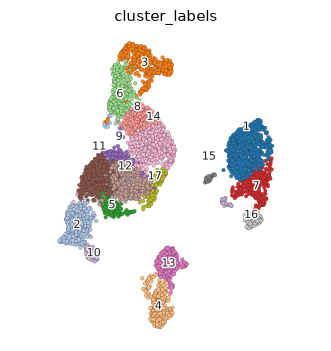

In [7]:
final = result.finalAnalysis
if (
    final.cellSelection is None
    or final.clusters is None
    or final.umap is None
    or final.markers is None
):
    raise RuntimeError("The completed final handoff is missing required artifacts")

final_store = scarf.DataStore(
    result.zarrPath,
    default_assay=final.primaryAssay,
    min_features_per_cell=-1,
    mito_pattern="",
    ribo_pattern="",
    zarr_mode="r",
    workspace=result.workflowRun.workspace,
    nthreads=2,
)
cell_selection_ref = artifact_model_to_ref(final.cellSelection)
cluster_ref = artifact_model_to_ref(final.clusters)
umap_ref = artifact_model_to_ref(final.umap)
marker_ref = artifact_model_to_ref(final.markers)

final_store.plots.embedding(
    layout=umap_ref,
    color_by=cluster_ref,
    legend_loc="on_data",
    frame="none",
)

In [8]:
marker_table = final_store.get_markers(
    marker=marker_ref,
    group_id=None,
    min_score=-1,
    min_frac_exp=-1,
)
marker_table.sort_values(
    ["group_id", "score"],
    ascending=[True, False],
).groupby("group_id", sort=True).head(2)[
    ["group_id", "feature_name", "score", "frac_exp"]
].head(12)

,group_id,feature_name,score,frac_exp
0,1,S100A12,0.74138,0.98516
1,1,QPCT,0.73460,0.53116
13908,10,AL022069.1,0.13879,0.04211
13909,10,AC073320.1,0.13770,0.04211
27816,11,ADTRP,0.23332,0.23611
27817,11,FHIT,0.20566,0.58333
41724,12,ANKRD55,0.25200,0.16746
41725,12,ADTRP,0.24974,0.24242
55632,13,TCL1A,0.85308,0.96578
55633,13,IGHD,0.76887,1.00000


In [9]:
report_path = generate_agent_report(
    result.zarrPath,
    result.workflowRun.workflowRunId,
    workspace=result.workflowRun.workspace,
)
display_path = str(report_path.relative_to(Path(result.zarrPath).parent)).replace(
    result.workflowRun.workflowRunId,
    "<workflowRunId>",
)

{
    "report": display_path,
    "exists": report_path.is_file(),
    "final_artifact_kinds": {
        "selection": cell_selection_ref.kind,
        "clusters": cluster_ref.kind,
        "umap": umap_ref.kind,
        "markers": marker_ref.kind,
    },
}

{'report': 'agent_workflow.zarr/agents/runs/<workflowRunId>/report/index.html',
 'exists': True,
 'final_artifact_kinds': {'selection': 'cell_selection',
  'clusters': 'cluster_labels',
  'umap': 'embedding',
  'markers': 'marker_table'}}